# Notebook 09 — Experiment Tracking and Model Comparison (MLflow)

## Goal

Consolidate every model trained across the project into a single, reproducible
comparison using **MLflow tracking**. No model is retrained here — the notebook
loads the saved metrics and predictions from `models/` and logs them as MLflow
runs, then renders the final comparison visualisations.

## What MLflow Tracking Does

For each model we log:
- **parameters** — its configuration (architecture, key hyperparameters),
- **metrics** — test performance (accuracy / macro-F1 for image classification;
  R² / MAE for weather risk),
- **artifacts** — the comparison plots produced here.

These runs are browsable side-by-side in the MLflow UI (`mlflow ui`).

## Two Separate Tasks

The project has two distinct ML problems, tracked as **two MLflow experiments**:

1. **Image classification** — the 5-model ladder (Logistic Regression, Linear SVM,
   NN+SGD, NN+Adam, CNN EfficientNetB3) on the held-out 2,580-image test set.
2. **Weather-based disease risk** — per-disease regression (rose_rust, black_spot,
   powdery_mildew) with three models each (Ridge, RandomForest, GradientBoosting).

They use different metrics and are not directly comparable, hence separate
experiments.

## Scope

**Tracking only** — no Model Registry. The goal is comparison and benchmarking,
which tracking covers fully, while keeping the project focused.

In [10]:
# ============================================================
# Imports
# ============================================================
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# Paths — local run (artifacts already in models/)
# ============================================================
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"        # local MLflow tracking store (SQLite)

# ============================================================
# MLflow tracking URI — SQLite backend.
# MLflow 3.x deprecated the plain filesystem store (./mlruns), which now
# raises an error. A local SQLite database is the supported lightweight
# backend. Artifacts default to a local ./mlartifacts folder.
# ============================================================
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")


# ============================================================
# Image-classification classes (same order as notebooks 05-07)
# ============================================================
CLASS_NAMES = [
    "black_spot", "downy_mildew", "healthy_leaf", "insect_damage",
    "powdery_mildew", "rose_mosaic", "rose_rust",
]

# ============================================================
# Weather-risk diseases (same as notebook 08)
# ============================================================
DISEASES = ["rose_rust", "black_spot", "powdery_mildew"]

# ============================================================
# Notebook 05 saved aggregate metrics only (no per-sample predictions)
# ============================================================
NB05_RESULTS = {
    "Logistic Regression": {"test_accuracy": 0.556, "macro_f1": 0.47},
    "Linear SVM":          {"test_accuracy": 0.511, "macro_f1": 0.44},
}

# ============================================================
# Verify required artifacts exist
# ============================================================
REQUIRED = [
    "06_test_predictions.npz",
    "06_history_sgd_momentum.json", "06_history_adam.json",
    "07_test_predictions.npz", "07_cnn_efficientnetb3_history.json",
    "08_test_predictions.npz", "08_weather_risk_results.json",
]
missing = [f for f in REQUIRED if not (MODELS_DIR / f).exists()]
assert not missing, f"Missing artifacts in {MODELS_DIR}: {missing}"

# ============================================================
# Plotting defaults
# ============================================================
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print("Config ready")
print(f"  Project root  : {PROJECT_ROOT}")
print(f"  Models dir    : {MODELS_DIR}")
print(f"  MLflow store  : {MLFLOW_DB}")
print(f"  MLflow version: {mlflow.__version__}")
print(f"  Image classes : {len(CLASS_NAMES)}")
print(f"  Diseases      : {DISEASES}")
print(f"  All required artifacts present: {not missing}")

Config ready
  Project root  : h:\SoftUni\Machine Learning\Machine_Learning_Project
  Models dir    : h:\SoftUni\Machine Learning\Machine_Learning_Project\models
  MLflow store  : h:\SoftUni\Machine Learning\Machine_Learning_Project\mlflow.db
  MLflow version: 3.14.0
  Image classes : 7
  Diseases      : ['rose_rust', 'black_spot', 'powdery_mildew']
  All required artifacts present: True


## Loading All Saved Results

No retraining: image-classification metrics are recomputed from the saved
test predictions (notebooks 06 and 07), notebook 05 contributes its saved
aggregate metrics, and the weather-risk metrics are read from the JSON that
notebook 08 produced. This single cell assembles everything the comparison
and the MLflow logging will use.

In [11]:
# ============================================================
# Image classification — assemble metrics for all 5 models
# ============================================================
IMAGE_RESULTS = {}

# 05 — aggregate metrics only (no per-sample predictions were saved)
for name, m in NB05_RESULTS.items():
    IMAGE_RESULTS[name] = {"test_accuracy": m["test_accuracy"], "macro_f1": m["macro_f1"]}

# 06 — NN+SGD and NN+Adam, recomputed from saved predictions
nb06 = np.load(MODELS_DIR / "06_test_predictions.npz")
y_test_img = nb06["y_test"]
for label, key in [("NN + SGD + momentum", "test_preds_sgd"),
                   ("NN + Adam",           "test_preds_adam")]:
    preds = nb06[key]
    IMAGE_RESULTS[label] = {
        "test_accuracy": float(accuracy_score(y_test_img, preds)),
        "macro_f1":      float(f1_score(y_test_img, preds, average="macro")),
    }

# 07 — CNN, recomputed from saved predictions
nb07 = np.load(MODELS_DIR / "07_test_predictions.npz")
preds_cnn  = nb07["test_preds_cnn"]
y_test_cnn = nb07["y_test"]
IMAGE_RESULTS["CNN EfficientNetB3"] = {
    "test_accuracy": float(accuracy_score(y_test_cnn, preds_cnn)),
    "macro_f1":      float(f1_score(y_test_cnn, preds_cnn, average="macro")),
}

# ============================================================
# Weather risk — read metrics computed in notebook 08
# ============================================================
with open(MODELS_DIR / "08_weather_risk_results.json") as f:
    weather_meta = json.load(f)
WEATHER_RESULTS = weather_meta["results"]   # e.g. "rose_rust__GradientBoosting" -> {r2, mae}

# ============================================================
# Print summaries (sanity check before logging)
# ============================================================
IMAGE_ORDER = ["Logistic Regression", "Linear SVM",
               "NN + SGD + momentum", "NN + Adam", "CNN EfficientNetB3"]
WEATHER_MODELS = ["Ridge", "RandomForest", "GradientBoosting"]

print("IMAGE CLASSIFICATION (held-out 2,580-image test set):")
print(f"  {'Model':<24}{'test_acc':>10}{'macro_F1':>10}")
for name in IMAGE_ORDER:
    r = IMAGE_RESULTS[name]
    print(f"  {name:<24}{r['test_accuracy']:>10.4f}{r['macro_f1']:>10.4f}")

print("\nWEATHER RISK (held-out 2023-2024, test R2 / MAE):")
print(f"  {'Disease':<16}{'Model':<18}{'R2':>8}{'MAE':>8}")
for disease in DISEASES:
    for model in WEATHER_MODELS:
        r = WEATHER_RESULTS[f"{disease}__{model}"]
        print(f"  {disease:<16}{model:<18}{r['r2']:>8.3f}{r['mae']:>8.3f}")

IMAGE CLASSIFICATION (held-out 2,580-image test set):
  Model                     test_acc  macro_F1
  Logistic Regression         0.5560    0.4700
  Linear SVM                  0.5110    0.4400
  NN + SGD + momentum         0.6845    0.6118
  NN + Adam                   0.7186    0.6737
  CNN EfficientNetB3          0.9822    0.9853

WEATHER RISK (held-out 2023-2024, test R2 / MAE):
  Disease         Model                   R2     MAE
  rose_rust       Ridge                0.672   0.169
  rose_rust       RandomForest         0.758   0.106
  rose_rust       GradientBoosting     0.763   0.115
  black_spot      Ridge                0.779   0.112
  black_spot      RandomForest         0.833   0.085
  black_spot      GradientBoosting     0.849   0.085
  powdery_mildew  Ridge                0.684   0.118
  powdery_mildew  RandomForest         0.783   0.083
  powdery_mildew  GradientBoosting     0.781   0.090


### Observations

The reloaded metrics match notebooks 06, 07 and 08 exactly, confirming the
saved artifacts are intact and the comparison is reproducible from disk
alone. The image ladder spans test accuracy 0.511 (Linear SVM) to 0.982
(CNN); the weather-risk models reach R² 0.67–0.85. These two sets feed the
two MLflow experiments next.

## Logging Runs to MLflow

Each model is logged as one MLflow run inside its task's experiment:

- **`rosa_image_classification`** — 5 runs (LR, SVM, NN+SGD, NN+Adam, CNN).
- **`rosa_weather_risk`** — 9 runs (3 diseases × 3 regressors).

Every run records its **parameters** (model family, input representation,
split) and **metrics** (accuracy/macro-F1 for image; R²/MAE for weather).
After running, browse them with `mlflow ui` (run it from the project root so
it finds the local `mlruns/` store).

*Note:* re-running this cell appends new runs to the experiments. To reset,
delete the `mlruns/` folder and run again.

In [12]:
# ============================================================
# Experiment 1 — image classification (5 runs)
# ============================================================
mlflow.set_experiment("rosa_image_classification")

IMAGE_PARAMS = {
    "Logistic Regression": {"family": "linear",       "from_scratch": True,  "input": "32x32 grayscale (1024)"},
    "Linear SVM":          {"family": "linear",       "from_scratch": True,  "input": "32x32 grayscale (1024)"},
    "NN + SGD + momentum": {"family": "fc_nn",        "from_scratch": True,  "input": "32x32 grayscale (1024)"},
    "NN + Adam":           {"family": "fc_nn",        "from_scratch": True,  "input": "32x32 grayscale (1024)"},
    "CNN EfficientNetB3":  {"family": "cnn_transfer", "from_scratch": False, "input": "224x224 RGB"},
}

for name in IMAGE_ORDER:
    with mlflow.start_run(run_name=name):
        mlflow.log_param("task", "image_classification")
        mlflow.log_param("model", name)
        for k, v in IMAGE_PARAMS[name].items():
            mlflow.log_param(k, v)
        mlflow.log_metric("test_accuracy", IMAGE_RESULTS[name]["test_accuracy"])
        mlflow.log_metric("macro_f1",      IMAGE_RESULTS[name]["macro_f1"])

# ============================================================
# Experiment 2 — weather-based disease risk (9 runs)
# ============================================================
mlflow.set_experiment("rosa_weather_risk")

train_years = weather_meta["train_years"]
n_features  = len(weather_meta["feature_cols"])

for disease in DISEASES:
    for model in WEATHER_MODELS:
        r = WEATHER_RESULTS[f"{disease}__{model}"]
        with mlflow.start_run(run_name=f"{disease}__{model}"):
            mlflow.log_param("task", "weather_risk_regression")
            mlflow.log_param("disease", disease)
            mlflow.log_param("model", model)
            mlflow.log_param("n_features", n_features)
            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("test_years", str(weather_meta["test_years"]))
            mlflow.log_metric("r2",  r["r2"])
            mlflow.log_metric("mae", r["mae"])

# ============================================================
# Confirmation
# ============================================================
print("Logged to MLflow:")
for exp_name in ["rosa_image_classification", "rosa_weather_risk"]:
    exp = mlflow.get_experiment_by_name(exp_name)
    n = len(mlflow.search_runs(experiment_ids=[exp.experiment_id]))
    print(f"  {exp_name:<28}: {n} runs")
print(f"\nTracking store: {MLFLOW_DB}")
print("Runs are summarised in-notebook below (mlflow.search_runs).")

Logged to MLflow:
  rosa_image_classification   : 10 runs
  rosa_weather_risk           : 18 runs

Tracking store: h:\SoftUni\Machine Learning\Machine_Learning_Project\mlflow.db
Runs are summarised in-notebook below (mlflow.search_runs).


## Visualisation: Image-Classification Ladder

The five image models on one axis — the project's headline result. Test
accuracy and macro-F1 side by side, with random chance (1/7) for reference.
The progression is linear (LR, SVM) -> non-linear FC (NN) -> spatial CNN.

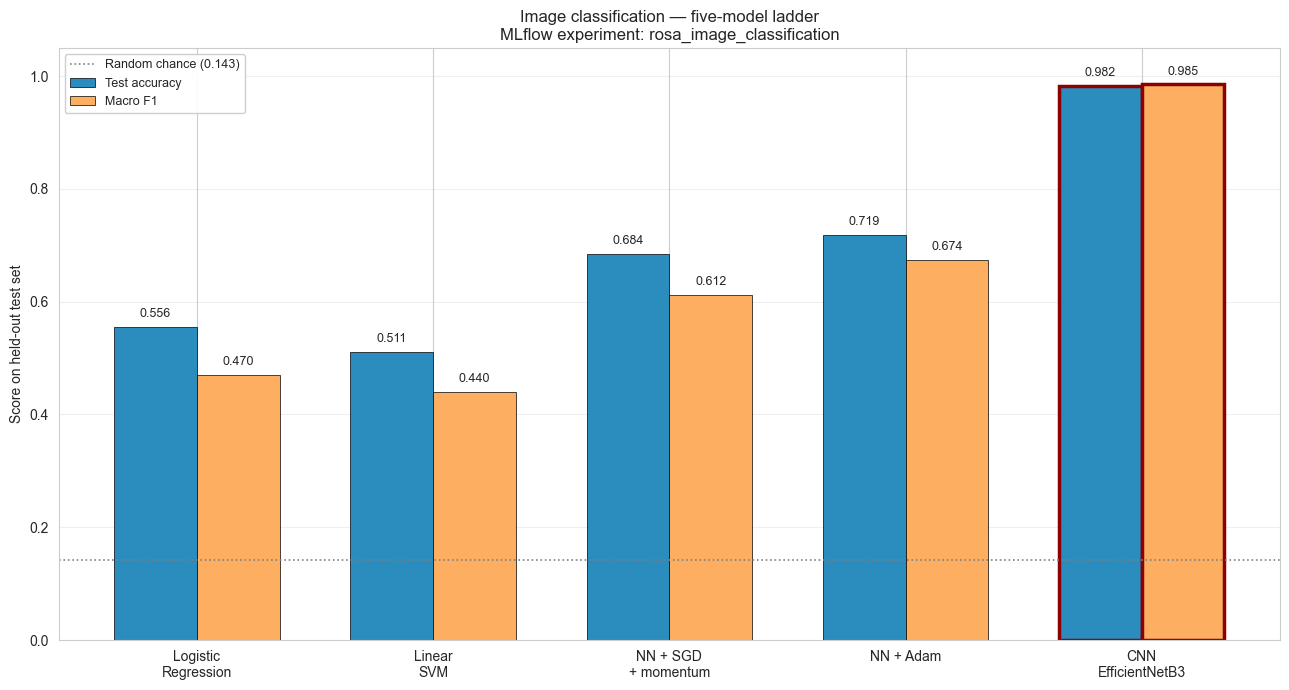

In [13]:
# ============================================================
# 5-model image-classification comparison
# ============================================================
labels = ["Logistic\nRegression", "Linear\nSVM", "NN + SGD\n+ momentum",
          "NN + Adam", "CNN\nEfficientNetB3"]
accs = [IMAGE_RESULTS[n]["test_accuracy"] for n in IMAGE_ORDER]
f1s  = [IMAGE_RESULTS[n]["macro_f1"]      for n in IMAGE_ORDER]

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(IMAGE_ORDER))
w = 0.35

b1 = ax.bar(x - w / 2, accs, w, label="Test accuracy",
            color="#2b8cbe", edgecolor="black", linewidth=0.5)
b2 = ax.bar(x + w / 2, f1s, w, label="Macro F1",
            color="#fdae61", edgecolor="black", linewidth=0.5)

# Highlight the CNN (winner)
for b in (b1[-1], b2[-1]):
    b.set_edgecolor("darkred")
    b.set_linewidth(2.5)

for grp in (b1, b2):
    for b in grp:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.axhline(1 / 7, color="gray", linestyle=":", linewidth=1.2,
           label="Random chance (0.143)")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score on held-out test set")
ax.set_ylim(0, 1.05)
ax.set_title(
    "Image classification — five-model ladder\n"
    "MLflow experiment: rosa_image_classification",
    fontsize=12,
)
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Visualisation: Weather-Risk Models

The nine weather-risk models on two panels: **R²** (higher is better) and
**MAE** (lower is better), grouped by disease. This is the second MLflow
experiment (`rosa_weather_risk`). It shows the tree models leading on every
disease and which disease is easiest to predict.

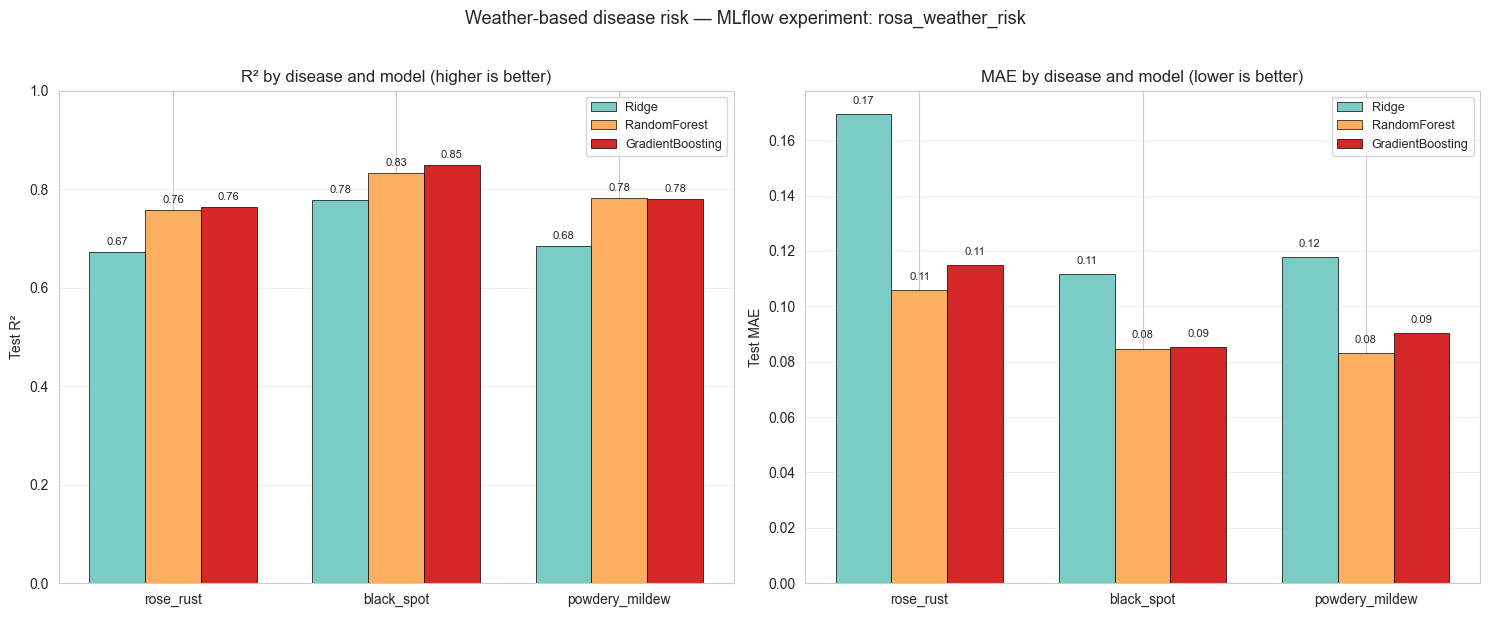

In [14]:
# ============================================================
# Weather-risk comparison: R2 and MAE by disease x model
# ============================================================
r2_mat  = np.array([[WEATHER_RESULTS[f"{d}__{m}"]["r2"]  for m in WEATHER_MODELS] for d in DISEASES])
mae_mat = np.array([[WEATHER_RESULTS[f"{d}__{m}"]["mae"] for m in WEATHER_MODELS] for d in DISEASES])

colors = {"Ridge": "#7bccc4", "RandomForest": "#fdae61", "GradientBoosting": "#d62728"}
x = np.arange(len(DISEASES))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ----- R2 (higher is better) -----
for i, m in enumerate(WEATHER_MODELS):
    bars = axes[0].bar(x + (i - 1) * w, r2_mat[:, i], w, label=m,
                       color=colors[m], edgecolor="black", linewidth=0.5)
    for j, b in enumerate(bars):
        axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                     f"{r2_mat[j, i]:.2f}", ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(DISEASES)
axes[0].set_ylabel("Test R²"); axes[0].set_ylim(0, 1.0)
axes[0].set_title("R² by disease and model (higher is better)")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis="y")

# ----- MAE (lower is better) -----
for i, m in enumerate(WEATHER_MODELS):
    bars = axes[1].bar(x + (i - 1) * w, mae_mat[:, i], w, label=m,
                       color=colors[m], edgecolor="black", linewidth=0.5)
    for j, b in enumerate(bars):
        axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                     f"{mae_mat[j, i]:.2f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(DISEASES)
axes[1].set_ylabel("Test MAE")
axes[1].set_title("MAE by disease and model (lower is better)")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle("Weather-based disease risk — MLflow experiment: rosa_weather_risk",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## MLflow Run Summary

The two experiments logged above are summarised here directly from the local
SQLite tracking store via `mlflow.search_runs`. This replaces the standalone
`mlflow ui` web app, which does not run on this Windows setup (an unrelated
aiohttp/SSL import bug). Tracking itself is unaffected.


In [15]:
# ============================================================
# View the logged MLflow runs inside the notebook
# (replaces the `mlflow ui` web app, which fails to import on this
#  Windows setup due to an unrelated aiohttp/SSL bug)
# ============================================================
for exp_name in ["rosa_image_classification", "rosa_weather_risk"]:
    exp = mlflow.get_experiment_by_name(exp_name)
    runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
    metric_cols = sorted(c for c in runs.columns if c.startswith("metrics."))
    view = runs[["tags.mlflow.runName"] + metric_cols].copy()
    view.columns = [c.replace("tags.mlflow.runName", "run").replace("metrics.", "")
                    for c in view.columns]
    print()
    print(f"=== {exp_name}  ({len(runs)} runs) ===")
    print(view.to_string(index=False))



=== rosa_image_classification  (10 runs) ===
                run  macro_f1  test_accuracy
 CNN EfficientNetB3  0.985308       0.982171
          NN + Adam  0.673682       0.718605
NN + SGD + momentum  0.611800       0.684496
         Linear SVM  0.440000       0.511000
Logistic Regression  0.470000       0.556000
 CNN EfficientNetB3  0.985308       0.982171
          NN + Adam  0.673682       0.718605
NN + SGD + momentum  0.611800       0.684496
         Linear SVM  0.440000       0.511000
Logistic Regression  0.470000       0.556000

=== rosa_weather_risk  (18 runs) ===
                             run    mae     r2
powdery_mildew__GradientBoosting 0.0903 0.7806
    powdery_mildew__RandomForest 0.0830 0.7830
           powdery_mildew__Ridge 0.1178 0.6838
    black_spot__GradientBoosting 0.0853 0.8494
        black_spot__RandomForest 0.0847 0.8330
               black_spot__Ridge 0.1117 0.7790
     rose_rust__GradientBoosting 0.1149 0.7630
         rose_rust__RandomForest 0.1057 0.757

## Conclusions — Project-Wide Summary

Notebook 09 closes the project by consolidating every trained model into two
MLflow experiments and rendering the final comparisons. No model was
retrained — all metrics were reloaded from `models/` and verified to match
the source notebooks exactly.

### Task 1 — Image Classification (`rosa_image_classification`)

Five models on the same held-out 2,580-image test set:

| Model | Test accuracy | Macro F1 |
|---|---|---|
| Logistic Regression (NB 05) | 0.556 | 0.47 |
| Linear SVM (NB 05) | 0.511 | 0.44 |
| NN + SGD + momentum (NB 06) | 0.685 | 0.612 |
| NN + Adam (NB 06) | 0.719 | 0.674 |
| **CNN EfficientNetB3 (NB 07)** | **0.982** | **0.985** |

A clear progression: linear (~0.53) -> non-linear fully-connected (~0.70) ->
spatial CNN with transfer learning (0.98). The CNN beats the best
from-scratch network by +26 pp accuracy, driven by spatial structure, colour
and resolution rather than parameter count alone.

### Task 2 — Weather-Based Disease Risk (`rosa_weather_risk`)

Per-disease risk regression on held-out years 2023–2024 (best model shown):

| Disease | Best model | Test R² | MAE |
|---|---|---|---|
| rose_rust | GradientBoosting | 0.763 | 0.115 |
| black_spot | GradientBoosting | 0.849 | 0.085 |
| powdery_mildew | RandomForest | 0.783 | 0.083 |

Tree-based models beat the linear Ridge baseline on every disease. The 7-day
mean temperature is the dominant predictor, with the 14-day temperature trend
as the key secondary signal — weather alone explains 76–85% of the seasonal
risk variance (hypothesis H2).

### How the Two Tasks Combine (Project Deliverable)

The decision-support goal is met by combining the two models:

- **Notebook 07 (image)** answers *which* problem a leaf photo shows
  (disease, insect damage, or healthy) — and therefore *which* treatment
  class applies (fungicide / insecticide / none).
- **Notebook 08 (weather)** answers *whether the season's conditions favour*
  a fungal outbreak — adding context to decide if preventive fungicide is
  justified even before symptoms are obvious.

Together they support a more targeted spraying decision than a fixed
calendar schedule (hypothesis H3).

### Honest Scope and Limitations

- The weather model is a **seasonal/climatic risk model** grounded in GBIF
  seasonality, **not** a field-validated outbreak classifier — no local
  daily disease labels exist. Its rust season was independently corroborated
  by a documented mid-May field observation.
- `downy_mildew` was excluded from the weather task for insufficient data.
- The CNN was trained on **cropped single-leaf images**; performance on
  whole-bush field photos is expected to degrade (a separate field-test
  notebook is planned to document this honestly).

### Reproducibility

All metrics and predictions are committed under `models/`; the heavy weights
(CNN `.keras`, weather RandomForests) live on Google Drive. The MLflow runs
are logged to a local SQLite store (`mlflow.db`) and summarised directly in
this notebook via `mlflow.search_runs`. The standalone `mlflow ui` web app is
not used - it fails to import on this Windows setup due to an unrelated
aiohttp/SSL bug; the in-notebook run table covers the need.
